In [1]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
from collections import Counter
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)





Mounted at /content/drive
Using device: cpu



# AGGRESSIVE DATA AUGMENTATION



In [2]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    ),
])


val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load dataset
dataset = datasets.ImageFolder(root='/content/drive/MyDrive/dataset', transform=train_transform)

print("="*60)
print("DATASET ANALYSIS")
print("="*60)
print(f"Classes: {dataset.classes}")
print(f"Total images: {len(dataset)}")

# Check per-class distribution
class_counts = Counter([label for _, label in dataset.samples])
print("\nImages per class:")
for class_idx, count in sorted(class_counts.items()):
    print(f"  {dataset.classes[class_idx]}: {count} images")



DATASET ANALYSIS
Classes: ['beurre', 'farine', 'lait']
Total images: 153

Images per class:
  beurre: 50 images
  farine: 52 images
  lait: 51 images


In [3]:




all_labels = [label for _, label in dataset.samples]


train_indices, val_indices = train_test_split(
    np.arange(len(dataset)),
    test_size=0.3,  # 30% for validation
    stratify=all_labels,
    random_state=42
)



train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)

print(f"\nDataset split (70/30):")
print(f"  Training: {len(train_dataset)} images")
print(f"  Validation: {len(val_dataset)} images")

# Verify validation split
val_labels = [dataset.samples[i][1] for i in val_indices]
val_class_counts = Counter(val_labels)
print(f"\nValidation distribution:")
for class_idx in range(len(dataset.classes)):
    count = val_class_counts.get(class_idx, 0)
    print(f"  {dataset.classes[class_idx]}: {count} images")

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16)





Dataset split (70/30):
  Training: 107 images
  Validation: 46 images

Validation distribution:
  beurre: 15 images
  farine: 16 images
  lait: 15 images


In [4]:

print("\n" + "="*60)
print("MODEL SETUP")
print("="*60)

# MobileNetV2 is lighter and better for small datasets
mobilenet = models.mobilenet_v2(pretrained=True)

# Freeze all layers except the last few  # Freeze early layers
for param in mobilenet.features[:-5].parameters():
    param.requires_grad = False



# Replace classifier
num_classes = len(dataset.classes)
mobilenet.classifier[1] = nn.Linear(1280, num_classes)

mobilenet = mobilenet.to(device)
print(f"Model: MobileNetV2")
print(f"Classes: {num_classes}")
print(f"Trainable parameters: {sum(p.numel() for p in mobilenet.parameters() if p.requires_grad):,}")

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, mobilenet.parameters()),
    lr=0.0003,  # learning rate for small datasets
    weight_decay=0.01  # Regularization to prevent overfitting
)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)



MODEL SETUP
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 13.6M/13.6M [00:00<00:00, 51.7MB/s]


Model: MobileNetV2
Classes: 3
Trainable parameters: 1,685,187


In [5]:

# TRAINING with Early Stopping

print("\n" + "="*60)
print("TRAINING STARTED")
print("="*60)

epochs = 30  # More epochs for small datasets
best_val_acc = 0.0
best_val_loss = float('inf')
best_model_score = -float('inf')
patience = 10
no_improve = 0

for epoch in range(epochs):
    # Training
    mobilenet.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = mobilenet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = correct / total
    train_loss = running_loss / len(train_loader)

    # Validation
    mobilenet.eval()
    val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = mobilenet(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_acc = correct_val / total_val
    val_loss_avg = val_loss / len(val_loader)

    # Update learning rate
    scheduler.step(val_acc)

    print(f"Epoch {epoch+1:3d}/{epochs} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss_avg:.4f}, Acc: {val_acc:.4f}")

    # Save best model
    model_score = val_acc - (0.1 * val_loss_avg)

    if model_score > best_model_score:
        best_model_score = model_score
        best_val_acc = val_acc
        best_val_loss = val_loss_avg
        torch.save(mobilenet.state_dict(), "/content/drive/MyDrive/mobilenet_products_best.pth")
        print(f"  ******* Best model saved! Val Acc: {val_acc:.4f}  **********")
        no_improve = 0
    else:
        no_improve += 1

    # Early stopping
    if no_improve >= patience:
        print(f"\n Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
        break

    # Overfitting warning
    if train_acc - val_acc > 0.2:
        print(f"   Overfitting detected (gap: {(train_acc - val_acc)*100:.1f}%)")

print(f"\nTraining complete!")
print(f"Best validation accuracy: {best_val_acc:.4f}")
print(f"Best validation loss: {best_val_loss:.4f}")



TRAINING STARTED
Epoch   1/30 | Train Loss: 0.7293, Acc: 0.6729 | Val Loss: 0.3331, Acc: 0.9565
  ******* Best model saved! Val Acc: 0.9565  **********
Epoch   2/30 | Train Loss: 0.1409, Acc: 0.9720 | Val Loss: 0.0991, Acc: 0.9783
  ******* Best model saved! Val Acc: 0.9783  **********
Epoch   3/30 | Train Loss: 0.0727, Acc: 0.9720 | Val Loss: 0.0324, Acc: 1.0000
  ******* Best model saved! Val Acc: 1.0000  **********
Epoch   4/30 | Train Loss: 0.0870, Acc: 0.9626 | Val Loss: 0.0088, Acc: 1.0000
  ******* Best model saved! Val Acc: 1.0000  **********
Epoch   5/30 | Train Loss: 0.0592, Acc: 0.9720 | Val Loss: 0.0117, Acc: 1.0000
Epoch   6/30 | Train Loss: 0.0628, Acc: 0.9720 | Val Loss: 0.0296, Acc: 1.0000
Epoch   7/30 | Train Loss: 0.0193, Acc: 0.9907 | Val Loss: 0.0454, Acc: 1.0000
Epoch   8/30 | Train Loss: 0.0120, Acc: 1.0000 | Val Loss: 0.0623, Acc: 0.9565
Epoch   9/30 | Train Loss: 0.0297, Acc: 0.9907 | Val Loss: 0.0794, Acc: 0.9783
Epoch  10/30 | Train Loss: 0.0351, Acc: 0.9813 

In [6]:
print("\n" + "="*60)
print("EVALUATION")
print("="*60)

mobilenet.load_state_dict(torch.load("/content/drive/MyDrive/mobilenet_products_best.pth"))
mobilenet.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = mobilenet(images)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Show predictions for each validation image
print("\nDétail des prédictions (validation):")
print("-" * 60)
for i in range(len(all_labels)):
    true_class = dataset.classes[all_labels[i]]
    pred_class = dataset.classes[all_preds[i]]
    status = "✓" if true_class == pred_class else "✗"
    print(f"{status} Image {i+1}: Vraie={true_class:10s} | Prédite={pred_class:10s}")

# Accuracy per class
print("\n PRÉCISION PAR CLASSE:")
print("-" * 60)
unique_labels = sorted(set(all_labels))
for label_idx in unique_labels:
    class_name = dataset.classes[label_idx]
    mask = all_labels == label_idx
    correct = (all_preds[mask] == label_idx).sum()
    total = mask.sum()
    acc = correct / total if total > 0 else 0
    print(f"{class_name:15s}: {acc*100:5.1f}% ({correct}/{total})")

print(f"\nPrécision globale: {(all_preds == all_labels).sum() / len(all_labels) * 100:.1f}%")


EVALUATION

Détail des prédictions (validation):
------------------------------------------------------------
✓ Image 1: Vraie=beurre     | Prédite=beurre    
✓ Image 2: Vraie=lait       | Prédite=lait      
✓ Image 3: Vraie=lait       | Prédite=lait      
✓ Image 4: Vraie=lait       | Prédite=lait      
✓ Image 5: Vraie=beurre     | Prédite=beurre    
✓ Image 6: Vraie=farine     | Prédite=farine    
✓ Image 7: Vraie=farine     | Prédite=farine    
✓ Image 8: Vraie=farine     | Prédite=farine    
✓ Image 9: Vraie=farine     | Prédite=farine    
✓ Image 10: Vraie=farine     | Prédite=farine    
✓ Image 11: Vraie=farine     | Prédite=farine    
✓ Image 12: Vraie=beurre     | Prédite=beurre    
✓ Image 13: Vraie=beurre     | Prédite=beurre    
✓ Image 14: Vraie=lait       | Prédite=lait      
✓ Image 15: Vraie=beurre     | Prédite=beurre    
✓ Image 16: Vraie=lait       | Prédite=lait      
✓ Image 17: Vraie=lait       | Prédite=lait      
✓ Image 18: Vraie=lait       | Prédite=lait     


MÉTRIQUES D'ÉVALUATION DÉTAILLÉES (MobileNetV2)

Loading best MobileNetV2 model...

 RAPPORT DE CLASSIFICATION
------------------------------------------------------------
              precision    recall  f1-score   support

      beurre     1.0000    1.0000    1.0000        15
      farine     1.0000    1.0000    1.0000        16
        lait     1.0000    1.0000    1.0000        15

    accuracy                         1.0000        46
   macro avg     1.0000    1.0000    1.0000        46
weighted avg     1.0000    1.0000    1.0000        46


 MATRICE DE CONFUSION
------------------------------------------------------------
[[15  0  0]
 [ 0 16  0]
 [ 0  0 15]]

 PRÉCISION PAR CLASSE
------------------------------------------------------------
beurre         : 100.00% (15/15)
farine         : 100.00% (16/16)
lait           : 100.00% (15/15)

 MÉTRIQUES GLOBALES
------------------------------------------------------------
Accuracy globale: 100.00%
Precision (macro): 100.00%
Recall 

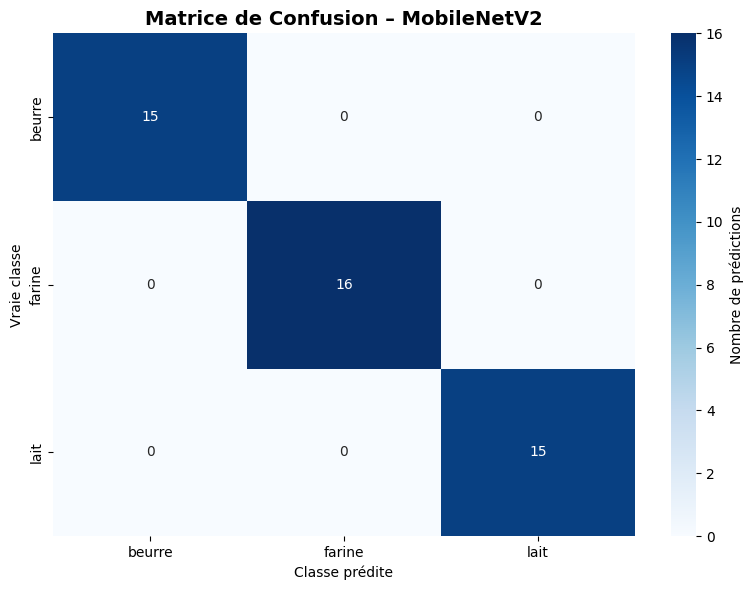

✓ Métriques par classe sauvegardées: metrics_per_class.png


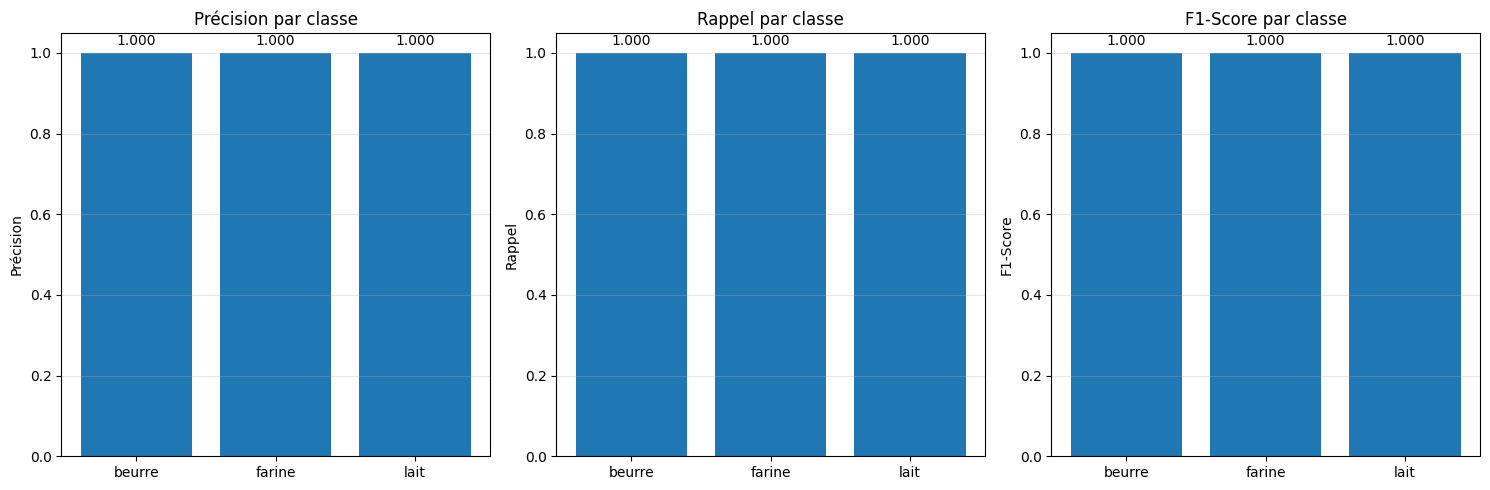

In [7]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import torch

print("\n" + "="*60)
print("MÉTRIQUES D'ÉVALUATION DÉTAILLÉES (MobileNetV2)")
print("="*60)



print("\nLoading best MobileNetV2 model...")
mobilenet.load_state_dict(
    torch.load("/content/drive/MyDrive/mobilenet_products_best.pth")
)
mobilenet.eval()

num_classes = len(dataset.classes)


all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = mobilenet(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)


# CLASSIFICATION REPORT
print("\n RAPPORT DE CLASSIFICATION")
print("-" * 60)
print(classification_report(
    all_labels,
    all_preds,
    target_names=dataset.classes,
    digits=4
))

# CONFUSION MATRIX
cm = confusion_matrix(all_labels, all_preds)

print("\n MATRICE DE CONFUSION")
print("-" * 60)
print(cm)


# PER-CLASS ACCURACY
print("\n PRÉCISION PAR CLASSE")
print("-" * 60)

for i, class_name in enumerate(dataset.classes):
    class_correct = cm[i, i]
    class_total = cm[i, :].sum()
    class_acc = class_correct / class_total if class_total > 0 else 0
    print(f"{class_name:15s}: {class_acc*100:5.2f}% ({class_correct}/{class_total})")


# GLOBAL METRICS
accuracy = np.trace(cm) / np.sum(cm)

print("\n MÉTRIQUES GLOBALES")
print("-" * 60)
print(f"Accuracy globale: {accuracy*100:.2f}%")

precision, recall, f1, support = precision_recall_fscore_support(
    all_labels,
    all_preds,
    average=None,
    labels=range(num_classes)
)

print(f"Precision (macro): {np.mean(precision)*100:.2f}%")
print(f"Recall (macro):    {np.mean(recall)*100:.2f}%")
print(f"F1-Score (macro):  {np.mean(f1)*100:.2f}%")

# CONFUSION MATRIX VISUALIZATION
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=dataset.classes,
    yticklabels=dataset.classes,
    cbar_kws={'label': 'Nombre de prédictions'}
)

plt.title('Matrice de Confusion – MobileNetV2', fontsize=14, fontweight='bold')
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')
plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/dataset/confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

print("\n✓ Matrice de confusion sauvegardée: confusion_matrix.png")
plt.show()


# PER-CLASS METRICS VISUALIZATION
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [precision, recall, f1]
metric_names = ['Précision', 'Rappel', 'F1-Score']

for idx, (metric, name) in enumerate(zip(metrics, metric_names)):
    axes[idx].bar(dataset.classes, metric)
    axes[idx].set_ylim([0, 1.05])
    axes[idx].set_ylabel(name)
    axes[idx].set_title(f'{name} par classe')
    axes[idx].grid(axis='y', alpha=0.3)

    for i, v in enumerate(metric):
        axes[idx].text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/dataset/metrics_per_class.png',
    dpi=300,
    bbox_inches='tight'
)

print("✓ Métriques par classe sauvegardées: metrics_per_class.png")
plt.show()


In [9]:

# EXPORT FOR ANDROID

print("\n" + "="*60)
print("EXPORT POUR ANDROID")
print("="*60)

mobilenet_cpu = mobilenet.cpu()
mobilenet_cpu.eval()

example_input = torch.randn(1, 3, 224, 224)

print("Tentative d'export...")
method_success = 0

# Try trace
try:
    with torch.no_grad():
        traced_model = torch.jit.trace(mobilenet_cpu, example_input)

    output_path = "/content/drive/MyDrive/mobilenet_products_mobile.pt"
    traced_model.save(output_path)

    # Test
    loaded = torch.jit.load(output_path)
    test_out = loaded(example_input)

    print(f" Export réussi!")
    method_success = 1

except Exception as e:
    print(f" Export échoué: {e}")

if method_success > 0:
    import os
    file_size = os.path.getsize(output_path)

    print(f"\n{'='*60}")
    print("EXPORT RÉUSSI!")
    print(f"{'='*60}")
    print(f"✓ Fichier: {output_path}")
    print(f"✓ Taille: {file_size / (1024*1024):.2f} MB")
    print(f"✓ Classes (Android): {dataset.classes}")

else:
    print("\n Export impossible")



EXPORT POUR ANDROID
Tentative d'export...
 Export réussi!

EXPORT RÉUSSI!
✓ Fichier: /content/drive/MyDrive/mobilenet_products_mobile.pt
✓ Taille: 9.07 MB
✓ Classes (Android): ['beurre', 'farine', 'lait']
